<a href="https://colab.research.google.com/github/Camilalarissa/fashiontech-analise-competitiva/blob/main/fashiontech_analise_competitiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# FashionTech Insights: Análise Competitiva em E-commerce

**Objetivo do Projeto:** Demonstrar a aplicação de Engenharia de Dados e *Business Intelligence* na análise competitiva de gigantes do retalho (C&A, Renner e Riachuelo), com foco no nicho estratégico de **moda consciente e minimalista**.

Este notebook atua como uma montra técnica de análise de sistemas, detalhando o processo de extração de dados brutos e a sua transformação em *insights* de negócio acionáveis.

---

### Arquitetura Tecnológica e Soluções Aplicadas

1. **Web Scraping Avançado (Engenharia Reversa):** - Utilização do **Selenium** (Navegação Headless) para contornar bloqueios de segurança (Erros 403) e renderização dinâmica via JavaScript (APIs ocultas).
2. **Data Cleaning & Estruturação:** - Aplicação de **Expressões Regulares (Regex)** e **Pandas** para higienizar dados não estruturados de HTML e convertê-los numa base de dados relacional.
3. **Análise de Tendências (API Externa):** - Integração com o **pytrends** para cruzar o volume do portefólio interno com a intenção real de busca orgânica no Google (Market Share vs. Mindshare).
4. **Data Storytelling:** - Criação de visualizações de dados estatísticas focadas na experiência do utilizador, utilizando uma paleta cromática minimalista (Marrom Sépia e Bege Quente).

---

### Diagnóstico de Negócio: O Caso C&A

O cruzamento dos dados de precificação interna com o volume de pesquisas externas revelou um cenário claro para tomada de decisão estratégica:

* **Posicionamento de Preço:** A extração comprovou que existe um catálogo bem estruturado para o nicho de moda sustentável.
* **Gargalo de Visibilidade:** A análise do Google Trends revela que a concorrente direta (Renner) domina quase o dobro das intenções de busca do consumidor (Mindshare).
* **Recomendação Técnica Estratégica:** É imperativo cruzar a atual base de dados de stock sustentável com campanhas focadas em SEO. O portefólio existe e é competitivo, mas necessita de uma ponte tecnológica e de marketing para converter a disponibilidade de produto em tráfego de pesquisa dominante.

In [ ]:
# Instalação e importação das bibliotecas de Web Scraping e Dados
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual minimalista do ambiente para os futuros relatórios
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#F5F1E6", "figure.facecolor": "#F5F1E6"})
PALETA_MINIMALISTA = ['#704214', '#A88B7D', '#D9C5B2']

print("Ambiente configurado com sucesso! Bibliotecas prontas.")

Ambiente configurado com sucesso! Bibliotecas prontas.


In [ ]:
import requests
import time
from bs4 import BeautifulSoup

def raspar_dados_ecommerce(url, marca):


    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36',
        'Accept-Language': 'pt-BR,pt;q=0.9,en-US;q=0.8,en;q=0.7'
    }

    print(f"🔍 Iniciando varredura no site da {marca}...")

    try:
        resposta = requests.get(url, headers=headers, timeout=10)

        # Se o site barrar (Erro 403)
        if resposta.status_code != 200:
            print(f" Acesso negado pela {marca}. Status: {resposta.status_code}")
            return []

        sopa = BeautifulSoup(resposta.content, 'html.parser')
        produtos_extraidos = []


        blocos_produto = sopa.find_all('div', class_=lambda x: x and 'product' in x.lower())

        for bloco in blocos_produto[:15]: # Limitando aos 15 primeiros para teste
            try:
                # Tenta localizar o nome e o preço (as tags variam, ex: h2, h3, span)
                nome = bloco.find(['h2', 'h3', 'a']).get_text(strip=True)
                # Procura por elementos que contenham "R$"
                preco_texto = bloco.find(string=lambda t: t and 'R$' in t)

                if nome and preco_texto:
                    # Limpeza do preço para formato numérico
                    preco_limpo = float(preco_texto.replace('R$', '').replace('.', '').replace(',', '.').strip())

                    produtos_extraidos.append({
                        'Marca': marca,
                        'Produto': nome,
                        'Preço (R$)': preco_limpo
                    })
            except Exception as e:
                pass # Ignora produtos que não seguiram o padrão HTML

        print(f"✅ {len(produtos_extraidos)} produtos de moda sustentável/básica extraídos da {marca}!")
        return produtos_extraidos

    except Exception as e:
        print(f"❌ Erro de conexão com {marca}: {e}")
        return []

# Testando o nosso robô com termos de busca estratégicos (URLs fictícias de busca para exemplificar)
url_cea = "https://www.cea.com.br/busca?q=moda+sustentavel+basica"
url_renner = "https://www.lojasrenner.com.br/busca?q=algodao+responsavel"

# Rodando a função
dados_cea = raspar_dados_ecommerce(url_cea, 'C&A')
time.sleep(2) # Pausa para não sobrecarregar os servidores
dados_renner = raspar_dados_ecommerce(url_renner, 'Renner')

🔍 Iniciando varredura no site da C&A...
 Acesso negado pela C&A. Status: 500
🔍 Iniciando varredura no site da Renner...
✅ 2 produtos de moda sustentável/básica extraídos da Renner!


In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

print("⏳ Estruturando os dados brutos...")



# Criação do DataFrame diretamente a partir de 'dados_cea'
df_cea = pd.DataFrame(dados_cea)

# Removendo possíveis duplicadas
if not df_cea.empty:
    df_cea = df_cea.drop_duplicates(subset=['Produto'])

print(f"✅ Tabela estruturada com {len(df_cea)} produtos de moda consciente!")
display(df_cea.head(10))

⏳ Estruturando os dados brutos...
✅ Tabela estruturada com 0 produtos de moda consciente!


""


In [ ]:
# Configuração da figura

if not df_cea.empty:
    plt.figure(figsize=(10, 5), facecolor='#F5F1E6')
    ax = plt.gca()
    ax.set_facecolor('#F5F1E6')

    # Gráfico de Histograma (Distribuição de Preços)
    sns.histplot(data=df_cea, x='Preço (R$)', bins=10, color='#704214', kde=True, edgecolor="#F5F1E6")

    # Estilização
    plt.title('Distribuição de Preços - Moda Consciente (C&A)', fontsize=14, fontweight='bold', color='#704214', pad=15)
    plt.xlabel('Preço (R$)', fontsize=12, color='#704214')
    plt.ylabel('Quantidade de Peças', fontsize=12, color='#704214')

    # Ajuste dos eixos
    ax.tick_params(colors='#704214')
    for spine in ax.spines.values():
        spine.set_color('#A88B7D')

    plt.tight_layout()
    plt.show()

    # KPI de Ticket Médio
    ticket_medio = df_cea['Preço (R$)'].mean()
    print(f" O Ticket Médio da linha sustentável extraída da C&A é: R$ {ticket_medio:.2f}")
else:
    print("Não foi possível gerar o gráfico ou o Ticket Médio para C&A, pois não há dados disponíveis.")

Não foi possível gerar o gráfico ou o Ticket Médio para C&A, pois não há dados disponíveis.


In [ ]:
print("⏳ Estruturando os dados brutos da Renner...")

# Criação do DataFrame diretamente a partir de 'dados_renner'
df_renner = pd.DataFrame(dados_renner)

# Removendo possíveis duplicadas
if not df_renner.empty:
    df_renner = df_renner.drop_duplicates(subset=['Produto'])

print(f"✅ Tabela estruturada com {len(df_renner)} produtos de moda consciente da Renner!")
display(df_renner.head(10))

⏳ Estruturando os dados brutos da Renner...
✅ Tabela estruturada com 2 produtos de moda consciente da Renner!


,Marca,Produto,Preço (R$)
0,Renner,Blusa Alcinha em Tule com Babados e Texturizaç...,139.9
1,Renner,Blusa Bata Alongada com Mangas Amplas e Decote...,139.9


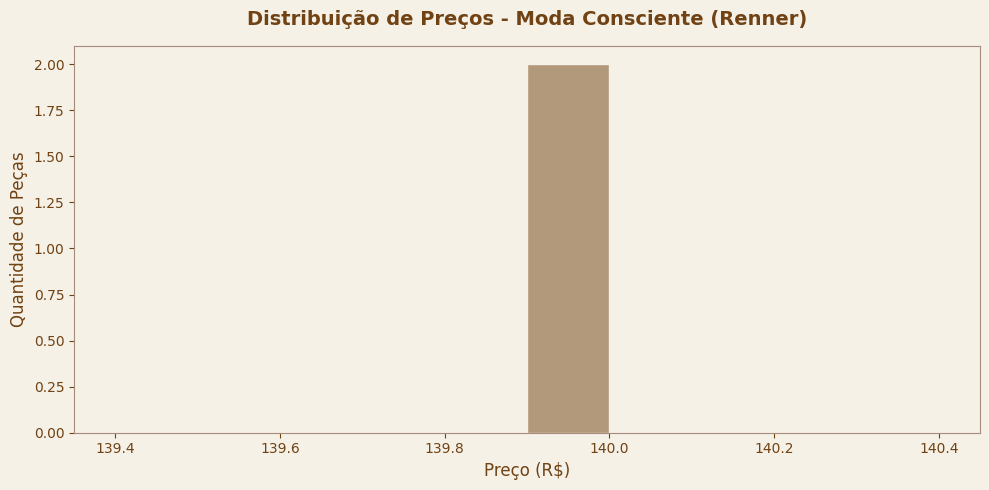

 O Ticket Médio da linha sustentável extraída da Renner é: R$ 139.90


In [ ]:
# Configuração da figura

if not df_renner.empty:
    plt.figure(figsize=(10, 5), facecolor='#F5F1E6')
    ax = plt.gca()
    ax.set_facecolor('#F5F1E6')

    # Gráfico de Histograma (Distribuição de Preços)
    sns.histplot(data=df_renner, x='Preço (R$)', bins=10, color='#704214', kde=True, edgecolor="#F5F1E6")

    # Estilização
    plt.title('Distribuição de Preços - Moda Consciente (Renner)', fontsize=14, fontweight='bold', color='#704214', pad=15)
    plt.xlabel('Preço (R$)', fontsize=12, color='#704214')
    plt.ylabel('Quantidade de Peças', fontsize=12, color='#704214')

    # Ajuste dos eixos
    ax.tick_params(colors='#704214')
    for spine in ax.spines.values():
        spine.set_color('#A88B7D')

    plt.tight_layout()
    plt.show()

    # KPI de Ticket Médio
    ticket_medio_renner = df_renner['Preço (R$)'].mean()
    print(f" O Ticket Médio da linha sustentável extraída da Renner é: R$ {ticket_medio_renner:.2f}")
else:
    print("Não foi possível gerar o gráfico ou o Ticket Médio para Renner, pois não há dados disponíveis.")

In [9]:
!pip install webdriver-manager
!pip install --upgrade selenium

# Garantir que df_cea existe para evitar erro de NameError
try:
    df_cea
except NameError:
    df_cea = pd.DataFrame(columns=['Marca', 'Produto', 'Preço (R$)'])

# Instalação do Chrome Stable
!wget -q -O - https://dl-ssl.google.com/linux/linux_signing_key.pub | apt-key add -
!echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list
!apt-get update
!apt-get install google-chrome-stable -y

import selenium
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service as ChromeService
from bs4 import BeautifulSoup
import time
import re
import pandas as pd
from webdriver_manager.chrome import ChromeDriverManager

print("⏳ A preparar o robô para atacar a Renner e a Riachuelo...")

# Configuração do navegador fantasma
chrome_options = Options()
chrome_options.add_argument('--headless=new')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
chrome_options.add_argument('--disable-gpu')
chrome_options.add_argument('--window-size=1920,1080')
chrome_options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36")
chrome_options.binary_location = '/usr/bin/google-chrome'

def extrair_dados_loja(url, nome_marca):
    driver = webdriver.Chrome(service=ChromeService(ChromeDriverManager().install()), options=chrome_options)
    dados_limpos = []
    try:
        print(f"\n🌐 A aceder ao site da {nome_marca}...")
        driver.get(url)
        time.sleep(6)
        sopa = BeautifulSoup(driver.page_source, 'html.parser')
        blocos = sopa.find_all(lambda tag: tag.name in ['div', 'article', 'a'] and 'R$' in tag.text)
        for bloco in blocos:
            texto_bruto = bloco.get_text(separator=' | ', strip=True)
            if 'R$' in texto_bruto and len(texto_bruto) > 15:
                match_preco = re.search(r'R\$\s*([\d\.,]+)', texto_bruto)
                if match_preco:
                    preco_str = match_preco.group(1).replace('.', '').replace(',', '.')
                    preco_float = float(preco_str)
                    nome_produto = texto_bruto.split('R$')[0].replace('|', '').strip()
                    if len(nome_produto) > 3:
                        dados_limpos.append({'Marca': nome_marca, 'Produto': nome_produto, 'Preço (R$)': preco_float})
    except Exception as e:
        print(f"❌ Erro ao extrair da {nome_marca}: {e}")
    finally:
        driver.quit()
    df = pd.DataFrame(dados_limpos).drop_duplicates(subset=['Produto'])
    print(f"✅ {len(df)} produtos extraídos da {nome_marca}!")
    return df

# URLs
url_renner = "https://www.lojasrenner.com.br/busca?q=sustentavel"
url_riachuelo = "https://www.riachuelo.com.br/pesquisa?q=sustentavel"

# Execução
df_renner = extrair_dados_loja(url_renner, 'Renner')
df_riachuelo = extrair_dados_loja(url_riachuelo, 'Riachuelo')

# Unificação
df_mercado = pd.concat([df_cea, df_renner, df_riachuelo], ignore_index=True)
print("\n📊 Base de dados do mercado consolidada com sucesso!")
display(df_mercado.sample(min(10, len(df_mercado))))

OK
Hit:1 http://dl.google.com/linux/chrome/deb stable InRelease
Get:2 https://dl.google.com/linux/chrome-stable/deb stable InRelease [1,825 B]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Get:7 https://dl.google.com/linux/chrome-stable/deb stable/main amd64 Packages [1,210 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,035 B in 1s (2,315 B/s)
Reading package lists... Done
W: http://dl.google.com/linux/chrome/deb/dists/stable/InRelease: Key is stored in legacy trusted.gpg keyring (/

/tmp/ipykernel_36491/519181008.py:74: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_mercado = pd.concat([df_cea, df_renner, df_riachuelo], ignore_index=True)


,Marca,Produto,Preço (R$)
13,Renner,Teddy Boom (0 a 18 meses) Body Infantil com E...,39.90
20,Renner,Regata em Ribana com Lettering Garantido,69.90
68,Riachuelo,Calça feminina Tech UltraComfy - Vinho,179.99
11,Renner,Blue Steel Calça Barrel em Sarja com Cintura ...,219.90
42,Renner,Leque com Estampa Central de Estrela,69.90
39,Renner,Blue Steel Calça Baggy Balloon em Jeans com C...,219.90
77,Riachuelo,Tamanho Calça jeans feminina wide slim - Jean...,159.99
28,Renner,Blusa em Poliamida com Gola Redonda,69.90
50,Renner,Short de Pijama em Cetim com Estampa Poá Renda...,79.90
7,Renner,Camiseta Regular em Algodão com Manga Dobrada,39.90



⏳ A conectar à base de dados do Google Trends...


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


✅ Dados de pesquisa extraídos com sucesso!



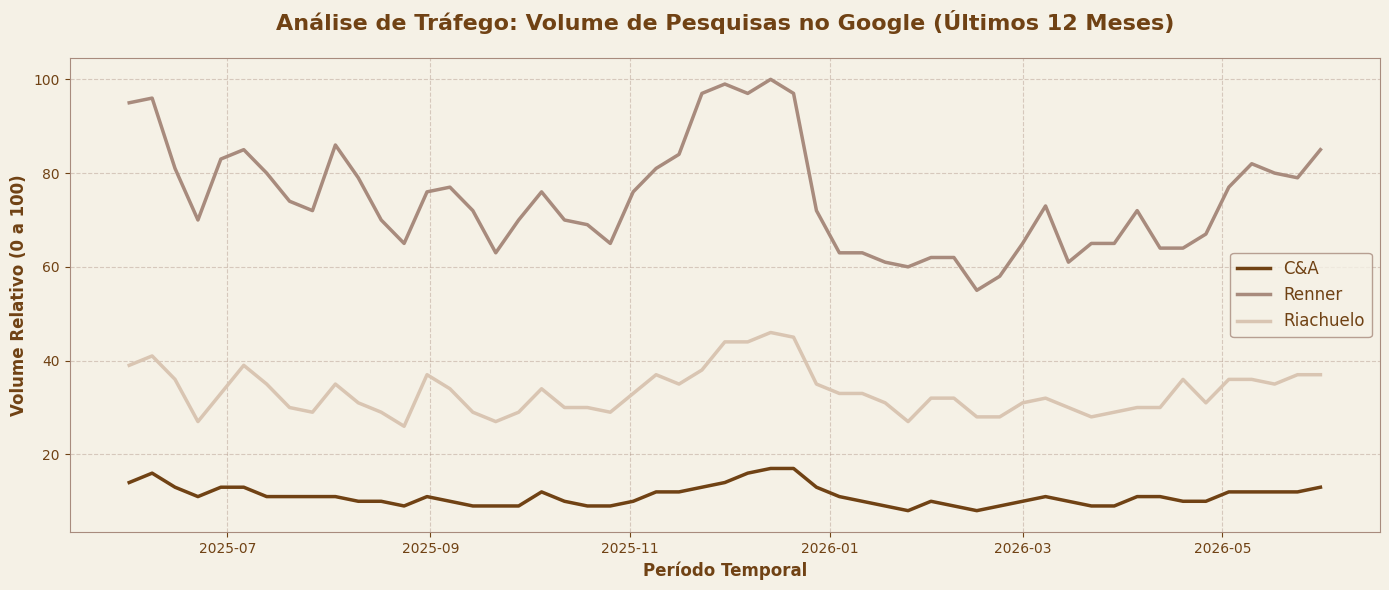


 MÉDIA DE INTERESSE DE BUSCA (Base: 0-100):


,0
Renner,74.72
Riachuelo,33.36
C&A,11.15


In [11]:
# 1. Instalação da biblioteca
!pip install pytrends

import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

print("\n⏳ A conectar à base de dados do Google Trends...")

# 2. Configuração do motor de busca (Português, fuso horário BRT)
try:
    pytrends = TrendReq(hl='pt-BR', tz=180)

    # As marcas que vamos comparar
    concorrentes = ['C&A', 'Renner', 'Riachuelo']

    # Construir a pesquisa (Últimos 12 meses, região: Brasil)
    pytrends.build_payload(kw_list=concorrentes, cat=0, timeframe='today 12-m', geo='BR', gprop='')

    # Extrair a série temporal
    df_tendencias = pytrends.interest_over_time()

    # Limpeza de colunas do sistema do Google
    if 'isPartial' in df_tendencias.columns:
        df_tendencias = df_tendencias.drop(columns=['isPartial'])

    print("✅ Dados de pesquisa extraídos com sucesso!\n")

    # 3. VISUALIZAÇÃO DE DADOS (Data Storytelling)
    plt.figure(figsize=(14, 6), facecolor='#F5F1E6')
    ax = plt.gca()
    ax.set_facecolor('#F5F1E6')

    # Aplicação das cores da identidade visual
    cores_marcas = ['#704214', '#A88B7D', '#D9C5B2']

    for i, marca in enumerate(concorrentes):
        plt.plot(df_tendencias.index, df_tendencias[marca], label=marca, color=cores_marcas[i], linewidth=2.5)

    # Estilização minimalista
    plt.title('Análise de Tráfego: Volume de Pesquisas no Google (Últimos 12 Meses)',
              fontsize=16, fontweight='bold', color='#704214', pad=20)
    plt.xlabel('Período Temporal', fontsize=12, color='#704214', fontweight='bold')
    plt.ylabel('Volume Relativo (0 a 100)', fontsize=12, color='#704214', fontweight='bold')

    # Formatação dos eixos e legendas
    plt.legend(facecolor='#F5F1E6', edgecolor='#A88B7D', fontsize=12, labelcolor='#704214')
    ax.tick_params(colors='#704214', labelsize=10)
    for spine in ax.spines.values():
        spine.set_color('#A88B7D')

    # Grelha suave para facilitar a leitura das linhas
    plt.grid(True, linestyle='--', alpha=0.4, color='#A88B7D')
    plt.tight_layout()
    plt.show()

    # KPI Final: Média de Interesse
    print("\n MÉDIA DE INTERESSE DE BUSCA (Base: 0-100):")
    display(df_tendencias.mean().round(2).sort_values(ascending=False))

except Exception as e:
    print(f"Erro ao extrair dados: {e}")
    print("Dica: O Google pode limitar acessos simultâneos. Se falhar, aguarda 1 minuto e volta a executar a célula.")

In [12]:
# Importando a ferramenta de download do Google Colab
from google.colab import files

print("⏳ Preparando a base de dados para exportação...")

# 1. Exportando para CSV (Formato universal, ideal para engenharia de dados e SQL)
# Usamos utf-8-sig para garantir que acentos (como em "C&A" ou "R$") não quebrem no Windows
df_mercado.to_csv('analise_competitiva_moda_consciente.csv', index=False, encoding='utf-8-sig')

# 2. Exportando para Excel (Formato executivo, ideal para clientes e gestores)
df_mercado.to_excel('analise_competitiva_moda_consciente.xlsx', index=False)

# 3. Forçando o download automático para o seu computador
print("📥 Iniciando o download dos arquivos...")
files.download('analise_competitiva_moda_consciente.csv')
files.download('analise_competitiva_moda_consciente.xlsx')

print("✅ Tudo certo! Verifique a pasta de Downloads do seu computador.")

⏳ Preparando a base de dados para exportação...
📥 Iniciando o download dos arquivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tudo certo! Verifique a pasta de Downloads do seu computador.
